In [48]:
import os
os.getcwd()

'C:\\Users\\hhm18\\Desktop\\vllm_and_quantization'

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
with open("sweep_res/awq_summary.csv") as f:
    awq_model_data = pd.read_csv(f)
with open("sweep_res/origin_summary.csv") as f:
    origin_model_data = pd.read_csv(f)
    
awq_model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               21 non-null     int64  
 1   date                     21 non-null     object 
 2   endpoint_type            21 non-null     object 
 3   backend                  21 non-null     object 
 4   label                    0 non-null      float64
 5   model_id                 21 non-null     object 
 6   tokenizer_id             21 non-null     object 
 7   num_prompts              21 non-null     int64  
 8   request_rate             21 non-null     int64  
 9   burstiness               21 non-null     float64
 10  max_concurrency          0 non-null      float64
 11  duration                 21 non-null     float64
 12  completed                21 non-null     int64  
 13  failed                   21 non-null     int64  
 14  total_input_tokens       21 

In [51]:
ds = pd.concat([origin_model_data, awq_model_data], axis=0)

In [59]:
ds.head()

,Unnamed: 0,date,endpoint_type,backend,label,model_id,tokenizer_id,num_prompts,request_rate,burstiness,...,p99_tpot_ms,mean_itl_ms,median_itl_ms,std_itl_ms,p99_itl_ms,mean_e2el_ms,median_e2el_ms,std_e2el_ms,p99_e2el_ms,run_number
0,0,20251222-004920,openai,openai,NaN,./Qwen/Qwen3-0.6B,./Qwen/Qwen3-0.6B,200,1,1.0,...,27.218239,23.718233,21.901774,7.046383,55.773425,3097.167482,3093.377521,212.577428,3565.101165,0
1,1,20251222-005300,openai,openai,NaN,./Qwen/Qwen3-0.6B,./Qwen/Qwen3-0.6B,200,1,1.0,...,28.781793,25.272864,22.999424,7.819769,62.730578,3298.366570,3298.878866,195.881664,3752.917833,1
2,2,20251222-005637,openai,openai,NaN,./Qwen/Qwen3-0.6B,./Qwen/Qwen3-0.6B,200,1,1.0,...,28.290248,25.184667,23.361644,7.303053,57.069974,3284.658702,3280.054767,176.084834,3697.853258,2
3,3,20251222-005833,openai,openai,NaN,./Qwen/Qwen3-0.6B,./Qwen/Qwen3-0.6B,200,2,1.0,...,28.282226,25.215824,22.097588,9.490159,62.542796,3289.370815,3288.522864,178.134078,3731.683344,0
4,4,20251222-010030,openai,openai,NaN,./Qwen/Qwen3-0.6B,./Qwen/Qwen3-0.6B,200,2,1.0,...,28.883010,25.297591,22.561618,9.354909,61.944455,3301.132009,3285.506747,216.607718,3743.110477,1


In [53]:
# 过滤掉全部为0的columns
ds_clean = ds.dropna(axis=1, how="all")
ds_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 0 to 20
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               42 non-null     int64  
 1   date                     42 non-null     object 
 2   endpoint_type            42 non-null     object 
 3   backend                  42 non-null     object 
 4   model_id                 42 non-null     object 
 5   tokenizer_id             42 non-null     object 
 6   num_prompts              42 non-null     int64  
 7   request_rate             42 non-null     int64  
 8   burstiness               42 non-null     float64
 9   duration                 42 non-null     float64
 10  completed                42 non-null     int64  
 11  failed                   42 non-null     int64  
 12  total_input_tokens       42 non-null     int64  
 13  total_output_tokens      42 non-null     int64  
 14  request_throughput       42 non-n

In [54]:
# 按照后端分组，计算核心指标的平均值
comparison = ds_clean.groupby('model_id')[[
    'output_throughput', 
    'mean_ttft_ms', 
    'mean_tpot_ms', 
    'completed'
]].mean()

# 查看哪个后端的性价比（单位延迟下的吞吐量）最高
comparison['efficiency_score'] = comparison['output_throughput'] / comparison['mean_tpot_ms']
comparison

,output_throughput,mean_ttft_ms,mean_tpot_ms,completed,efficiency_score
model_id,,,,,
./Qwen/Qwen3-0.6B,514.984862,5768.351286,31.468774,200.0,16.364948
./Qwen3-0.6B-awq-sym,547.908124,4784.261313,33.127567,200.0,16.539341


C:\Users\hhm18\AppData\Local\Temp\ipykernel_18664\2503497964.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds_clean['model_name'] = ds_clean['model_id'].apply(lambda x: 'Original' if 'awq' not in x else 'AWQ')


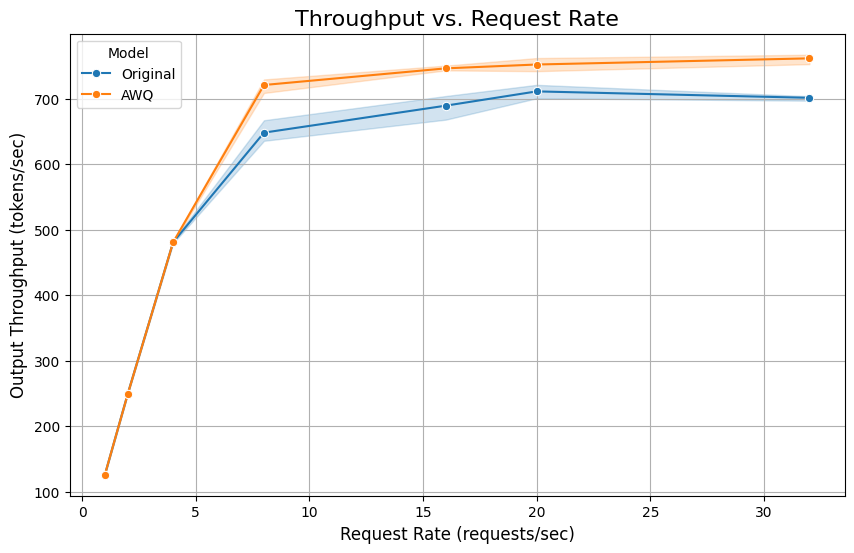

In [ ]:
# 为了图例清晰，创建一个更简洁的model_name列
ds_clean['model_name'] = ds_clean['model_id'].apply(lambda x: 'Original' if 'awq' not in x else 'AWQ')

# 1. 吞吐量 vs. 请求率
plt.figure(figsize=(10, 6))
sns.lineplot(data=ds_clean, x='request_rate', y='output_throughput', hue='model_name', marker='o')
plt.title('Throughput vs. Request Rate', fontsize=16)
plt.xlabel('Request Rate (requests/sec)', fontsize=12)
plt.ylabel('Output Throughput (tokens/sec)', fontsize=12)
plt.grid(True)
plt.legend(title='Model')
plt.show()

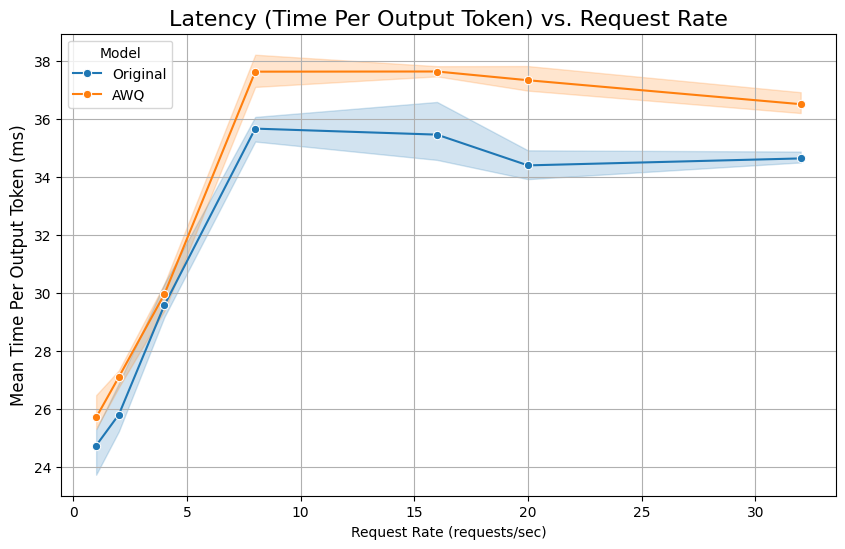

In [65]:
# 2. 延迟 vs. 请求率
plt.figure(figsize=(10, 6))
sns.lineplot(data=ds_clean, x='request_rate', y='mean_tpot_ms', hue='model_name', marker='o')
plt.title('Latency (Time Per Output Token) vs. Request Rate', fontsize=16)
plt.xlabel('Request Rate (requests/sec)', fontsize=10)
plt.ylabel('Mean Time Per Output Token (ms)', fontsize=12)
plt.grid(True)
plt.legend(title='Model')
plt.show()

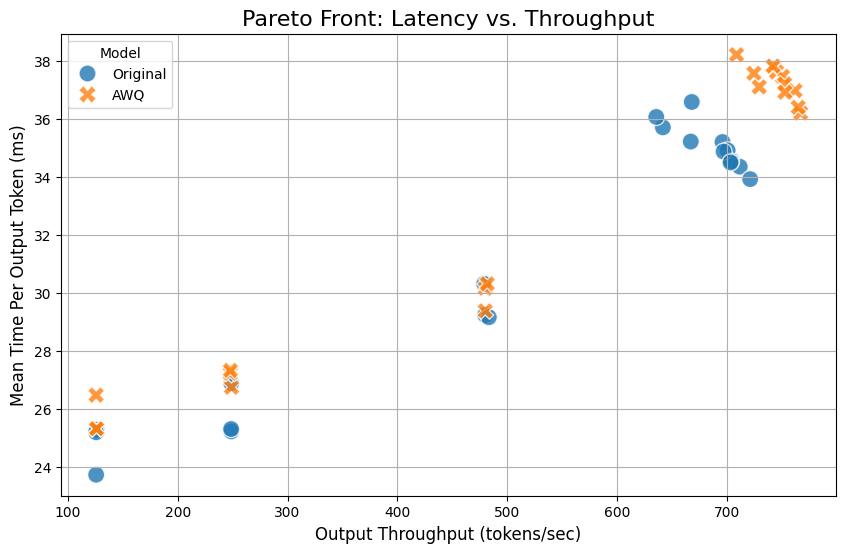

In [ ]:
# 3. 帕累托前沿 (Latency vs. Throughput)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ds_clean, 
                x='output_throughput', 
                y='mean_tpot_ms', 
                hue='model_name', 
                style='model_name', 
                s=150, 
                alpha=0.8)

plt.title('Pareto Front: Latency vs. Throughput', fontsize=16)
plt.xlabel('Output Throughput (tokens/sec)', fontsize=12)
plt.ylabel('Mean Time Per Output Token (ms)', fontsize=12)
plt.legend(title='Model')
plt.grid(True)
plt.show()